In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
import mdtraj

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)

rhresids = arange(292,496)
huresids = systems[1][0].residues.resids
    
protein=[]
proteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein"))
        sub2.append("protein")
        
    protein.append(sub)
    proteinstrings.append(sub2)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [3]:
allcontacts=load("allcontacts_mean.npy",allow_pickle = True)

In [4]:
allcontacts[0][0].shape

(20504,)

In [5]:
avg_contacts=[]
sem_contacts=[]
for i in range(len(allcontacts)):
    avg_contacts.append(mean(allcontacts[i],axis = 0))
    sem_contacts.append(scipy.stats.sem(list(allcontacts[i]),axis = 0))

In [6]:
sem_contacts

[array([0.00462849, 0.0003318 , 0.00075187, ..., 0.00011366, 0.01041423,
        0.        ]),
 array([0.00075097, 0.00743368, 0.00782473, ..., 0.00701898, 0.00016663,
        0.02094363]),
 array([0.00082767, 0.0028065 , 0.00318194, ..., 0.01056932, 0.        ,
        0.01652184])]

In [7]:
def BestTwoD(array1d):
    #The number of dimensions (excluding nearest neighbours and self)
    N = int(1.5 + .5*np.sqrt(1+(8*len(array1d))))

    #Construct a 2D version of the contact map (it excludes nearesty neighbours and self, but there are still NxN slots)
    twoD=zeros((N,N))            
    j=2
    k=0
    for i in range(len(array1d)):
        if abs(j-k)>1:
            twoD[j][k] = array1d[i]
            twoD[k][j] = array1d[i]
        j+=1
        if j == len(twoD):
            k+=1
            j = k+2
            if k==len(twoD)-2 and j >len(twoD)-2 :
                break
    return twoD




In [8]:
avg_contacts_2d =[]
sem_contacts_2d =[]
for i in range(len(avg_contacts)):
    avg_contacts_2d.append(BestTwoD(avg_contacts[i]))
    sem_contacts_2d.append(BestTwoD(sem_contacts[i]))

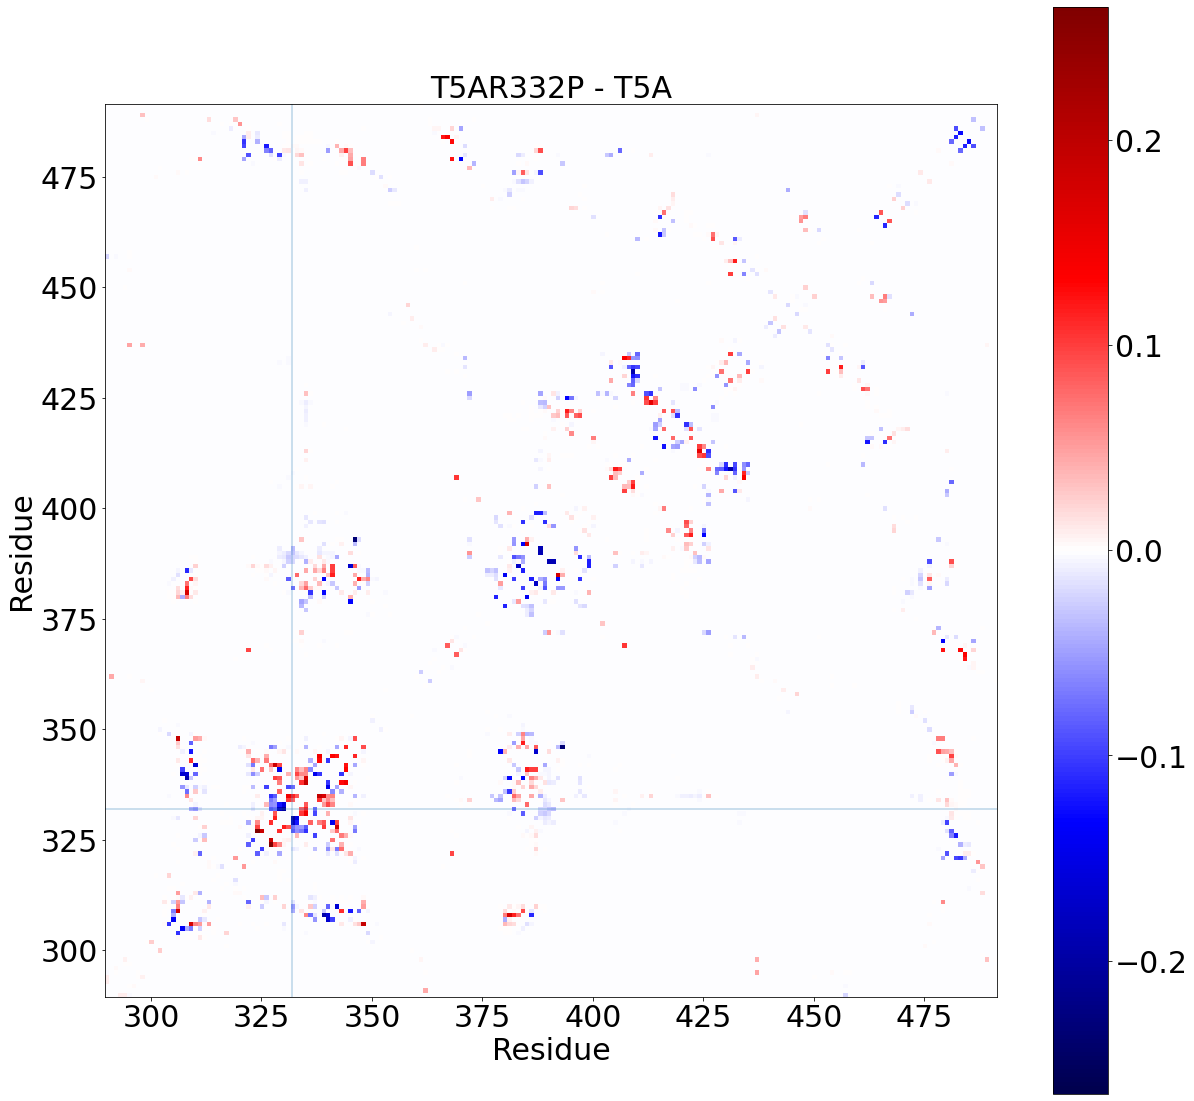

In [9]:
diffmap = avg_contacts_2d[2] - avg_contacts_2d[1]
semDiffBars = sqrt(sem_contacts_2d[2]**2 + sem_contacts_2d[1]**2)

significant_diffbars=copy(diffmap)
for i in range(len(diffmap)):
    for j in range(len(diffmap[i])):
        if abs(semDiffBars[i][j]) > abs(diffmap[i][j]):
            significant_diffbars[i][j] = 0

            
            
drange = max(abs(significant_diffbars).flatten())

figure(figsize = (20,20))
imshow(significant_diffbars,origin = "lower",cmap='seismic',vmin=-drange,vmax=drange,extent = (huresids[0]-0.5,huresids[-1]+0.5,huresids[0]-0.5,huresids[-1]+0.5))

#5.55.55.5
cbar=colorbar()
cbar.ax.tick_params(labelsize=30) 
xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
title(system_names[2] + " - " + system_names[1],fontsize = 30)
xticks(fontsize = 30)
yticks(fontsize = 30)
axvline(332,alpha = 0.3)
axhline(332,alpha = 0.3)

#xlim(415,430)
#ylim(380,400)

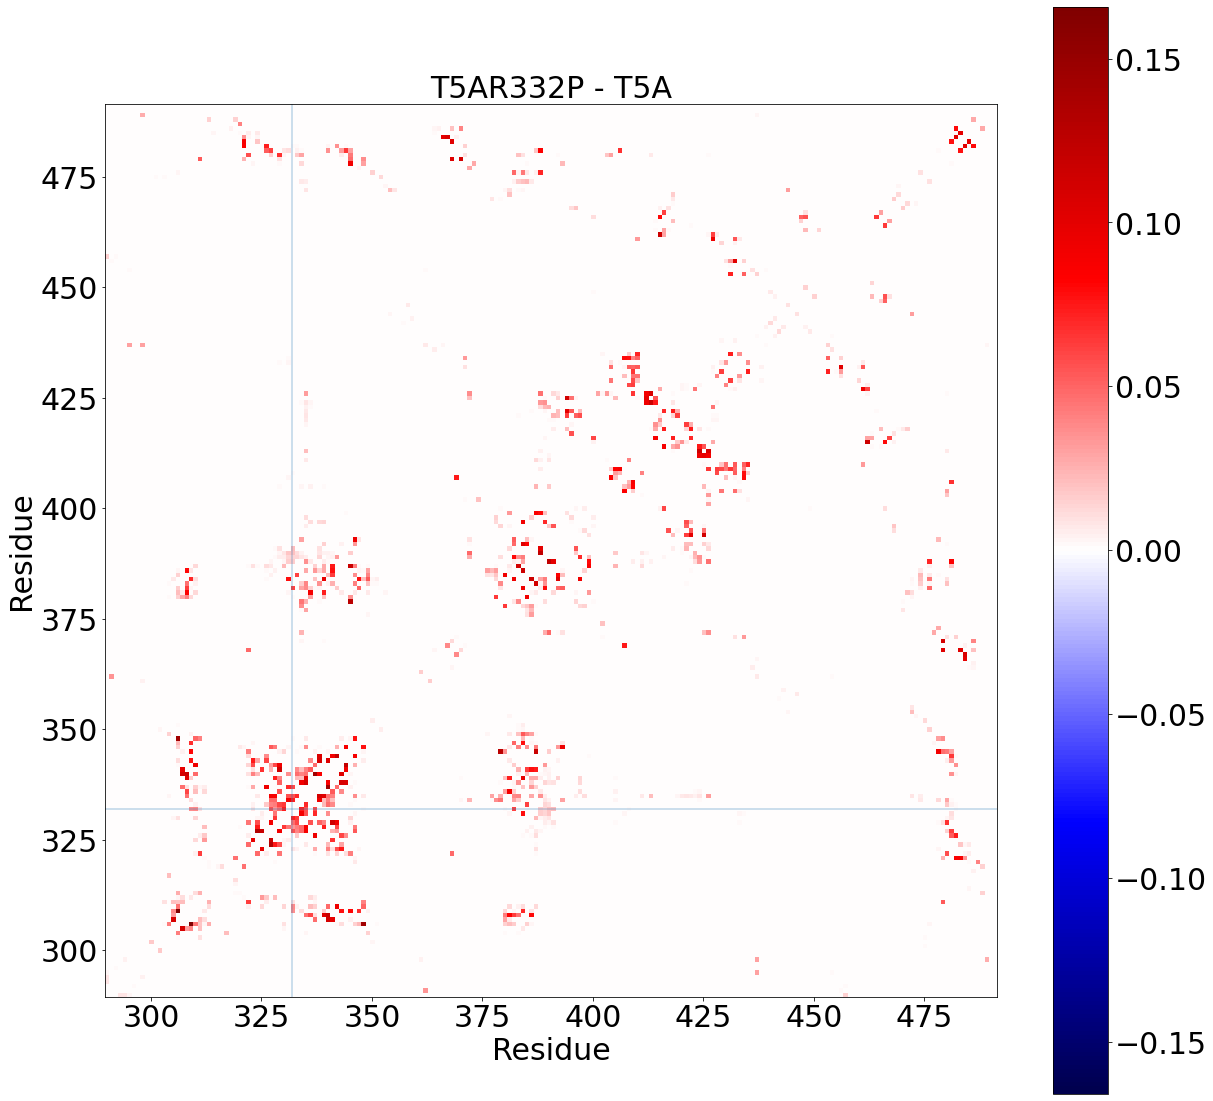

In [10]:
diffmap = avg_contacts_2d[2] - avg_contacts_2d[1]
semDiffBars = sqrt(sem_contacts_2d[2]**2 + sem_contacts_2d[1]**2)

significant_diffbars=copy(diffmap)
for i in range(len(diffmap)):
    for j in range(len(diffmap[i])):
        if abs(semDiffBars[i][j]) > abs(diffmap[i][j]):
            significant_diffbars[i][j] = 0
            semDiffBars[i][j] = 0
            
            
drange = max(abs(semDiffBars).flatten())

figure(figsize = (20,20))
imshow(semDiffBars,origin = "lower",cmap='seismic',vmin=-drange,vmax=drange,extent = (huresids[0]-0.5,huresids[-1]+0.5,huresids[0]-0.5,huresids[-1]+0.5))

#5.55.55.5
cbar=colorbar()
cbar.ax.tick_params(labelsize=30) 
xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
title(system_names[2] + " - " + system_names[1],fontsize = 30)
xticks(fontsize = 30)
yticks(fontsize = 30)
axvline(332,alpha = 0.3)
axhline(332,alpha = 0.3)

#xlim(415,430)
#ylim(380,400)

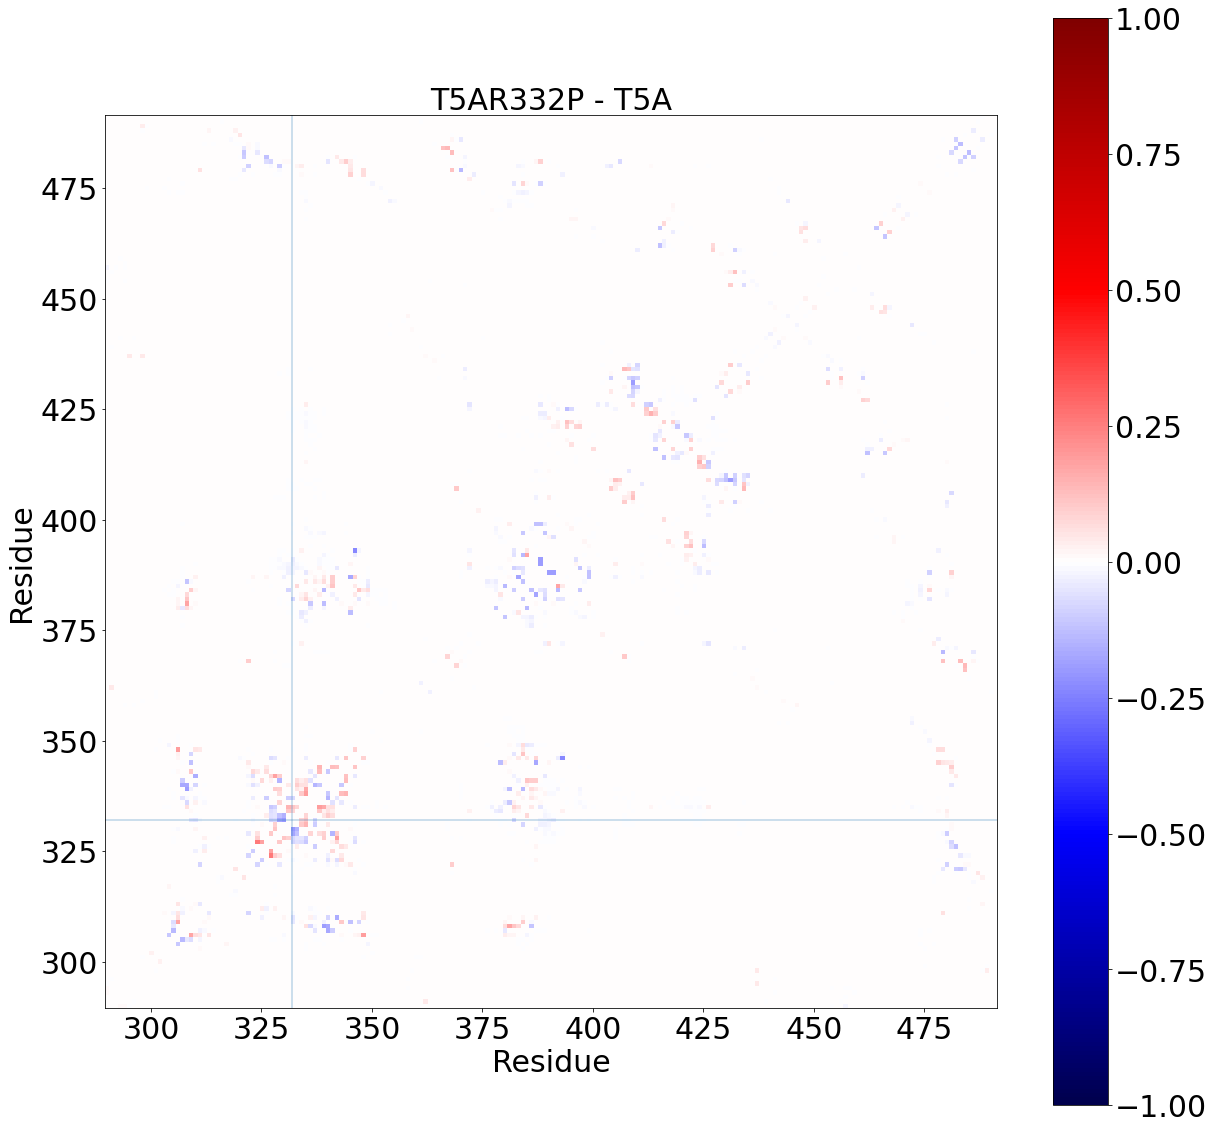

In [11]:
figure(figsize = (20,20))
imshow(significant_diffbars,origin = "lower",cmap='seismic',vmin=-1,vmax=1,extent = (huresids[0]-0.5,huresids[-1]+0.5,huresids[0]-0.5,huresids[-1]+0.5))

#5.55.55.5
cbar=colorbar()
cbar.ax.tick_params(labelsize=30) 
xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
title(system_names[2] + " - " + system_names[1],fontsize = 30)
xticks(fontsize = 30)
yticks(fontsize = 30)
axvline(332,alpha = 0.3)
axhline(332,alpha = 0.3)

#xlim(415,430)
#ylim(380,400)

(324.0, 350.0)

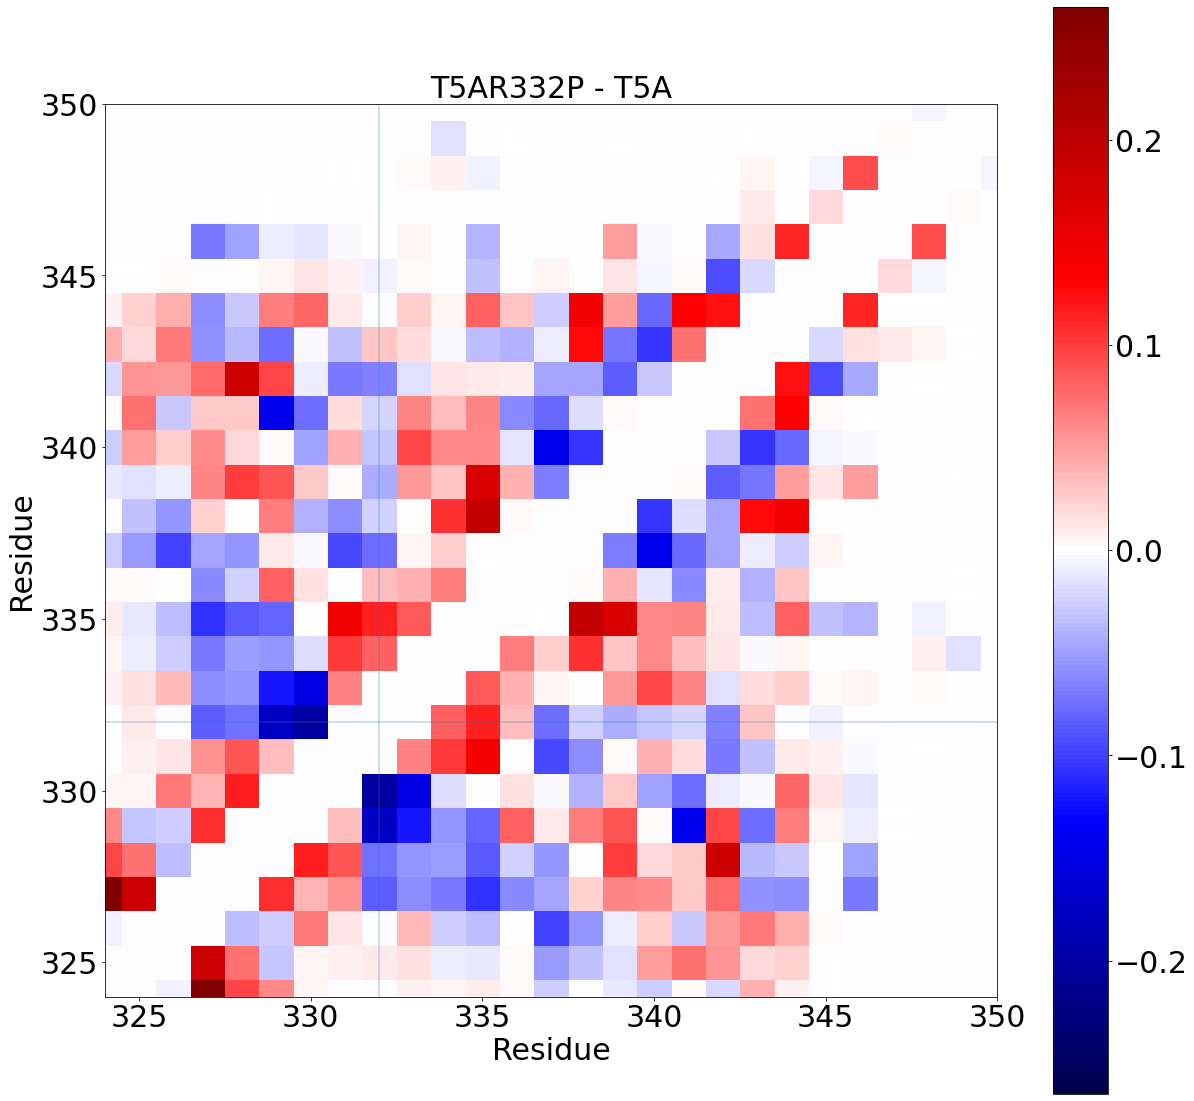

In [12]:
diffmap = avg_contacts_2d[2] - avg_contacts_2d[1]
semDiffBars = sqrt(avg_contacts_2d[2]**2 + avg_contacts_2d[1]**2)

drange = max(abs(diffmap).flatten())

figure(figsize = (20,20))
imshow(diffmap,origin = "lower",cmap='seismic',vmin=-drange,vmax=drange,extent = (huresids[0]-0.5,huresids[-1]+0.5,huresids[0]-0.5,huresids[-1]+0.5))

#5.55.55.5
cbar=colorbar()
cbar.ax.tick_params(labelsize=30) 
xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
title(system_names[2] + " - " + system_names[1],fontsize = 30)
xticks(fontsize = 30)
yticks(fontsize = 30)
axvline(332,alpha = 0.3)
axhline(332,alpha = 0.3)

xlim(324,350)
ylim(324,350)

(324.0, 350.0)

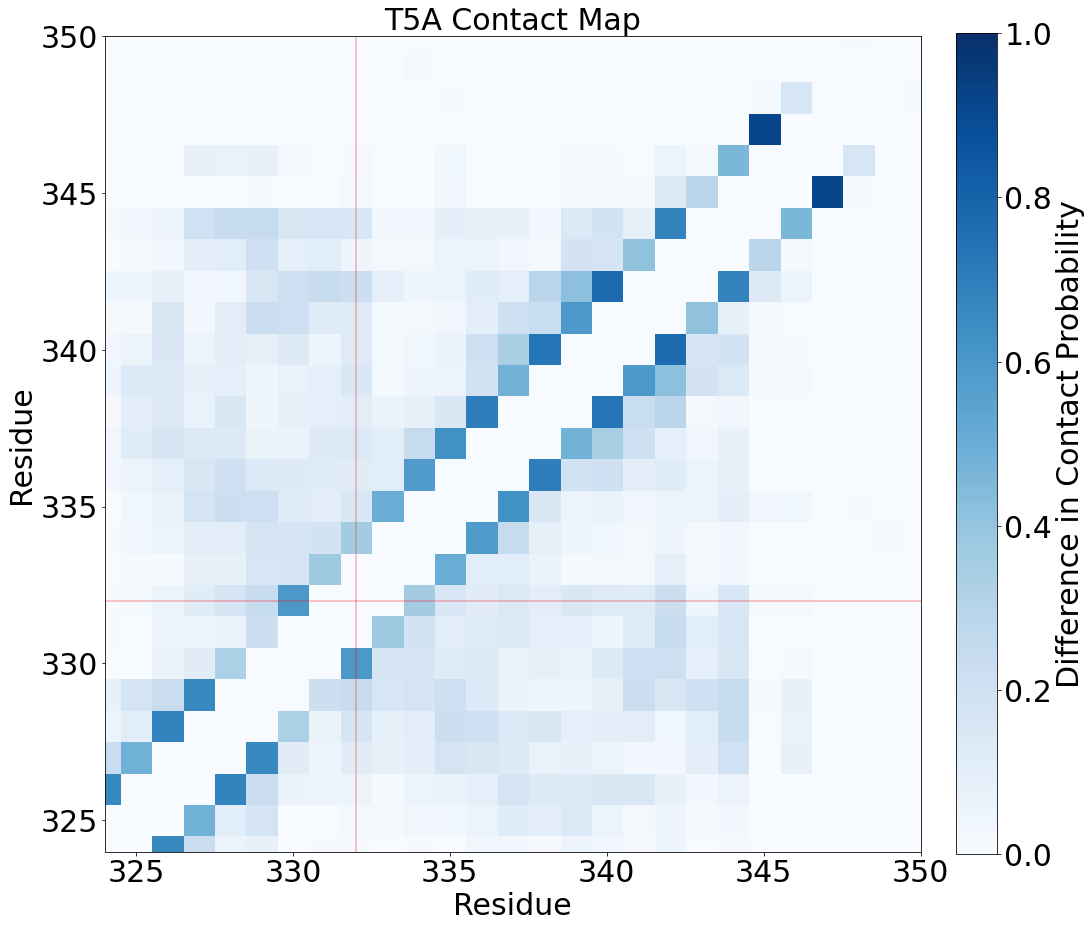

In [13]:


drange = max(abs(avg_contacts_2d[1]).flatten())

figure(figsize = (16,16))
imshow(avg_contacts_2d[1],origin = "lower",cmap='Blues',vmin=-0,vmax=drange,extent = (huresids[0]-0.5,huresids[-1]+0.5,huresids[0]-0.5,huresids[-1]+0.5))

#5.55.55.5
cbar=colorbar(fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=30) 
cbar.set_label("Difference in Contact Probability",fontsize = 30)
xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
title(system_names[1] + " Contact Map",fontsize = 30)
xticks(fontsize = 30)
yticks(fontsize = 30)
axvline(332,alpha = 0.3,color = "red")
axhline(332,alpha = 0.3,color = "red")

xlim(324,350)
ylim(324,350)

(324.0, 350.0)

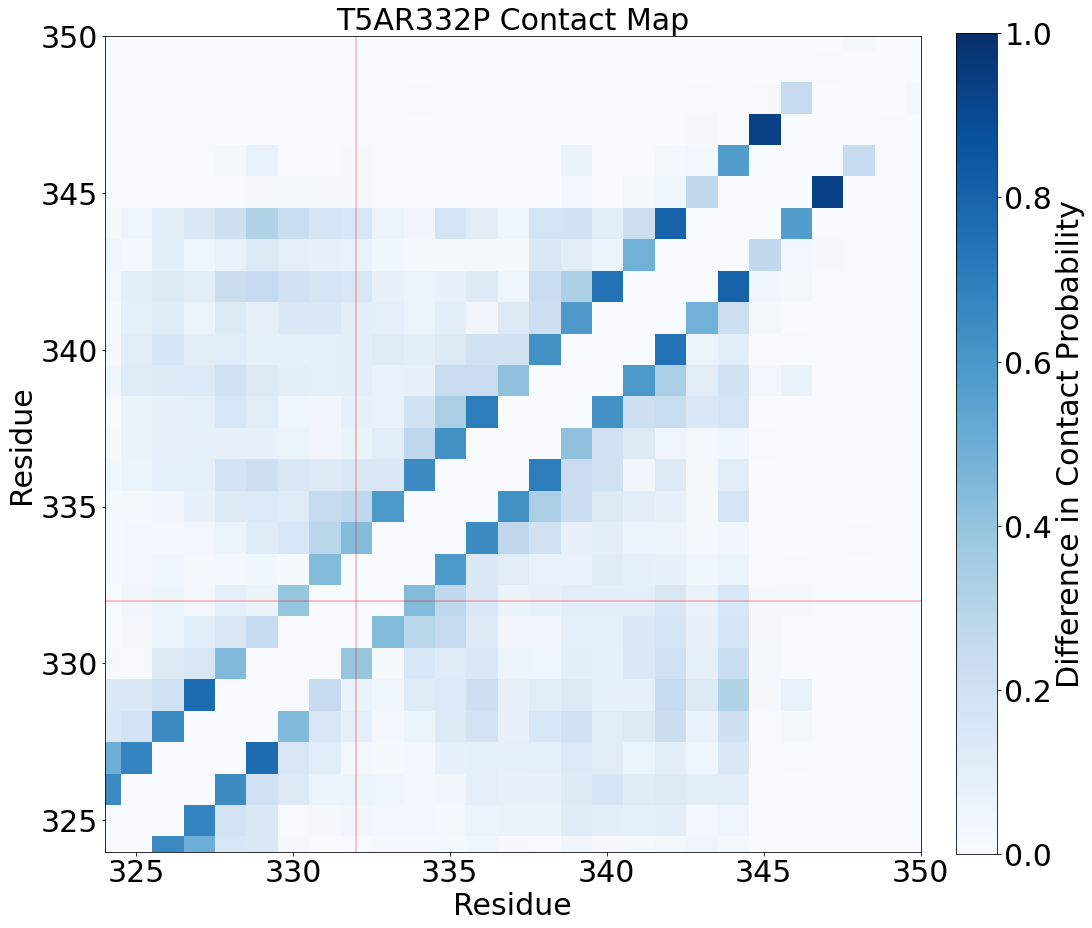

In [14]:


drange = max(abs(avg_contacts_2d[1]).flatten())

figure(figsize = (16,16))
imshow(avg_contacts_2d[2],origin = "lower",cmap='Blues',vmin=-0,vmax=drange,extent = (huresids[0]-0.5,huresids[-1]+0.5,huresids[0]-0.5,huresids[-1]+0.5))

#5.55.55.5
cbar=colorbar(fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=30) 
cbar.set_label("Difference in Contact Probability",fontsize = 30)
xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
title(system_names[2] + " Contact Map",fontsize = 30)
xticks(fontsize = 30)
yticks(fontsize = 30)
axvline(332,alpha = 0.3,color = "red")
axhline(332,alpha = 0.3,color = "red")

xlim(324,350)
ylim(324,350)

(324.0, 350.0)

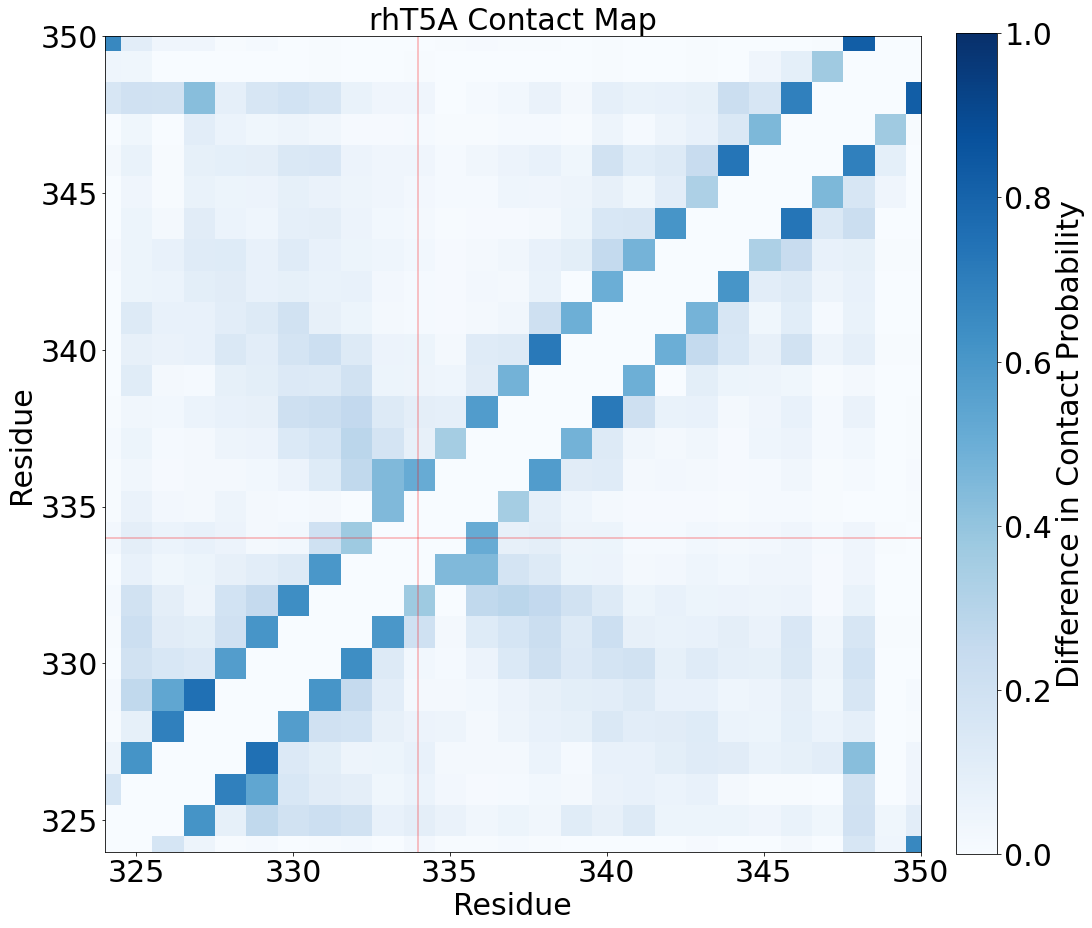

In [15]:


drange = max(abs(avg_contacts_2d[0]).flatten())

figure(figsize = (16,16))
imshow(avg_contacts_2d[0],origin = "lower",cmap='Blues',vmin=-0,vmax=drange,extent = (rhresids[0]-0.5,rhresids[-1]+0.5,rhresids[0]-0.5,rhresids[-1]+0.5))

#5.55.55.5
cbar=colorbar(fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=30) 
cbar.set_label("Difference in Contact Probability",fontsize = 30)
xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
title(system_names[0] + " Contact Map",fontsize = 30)
xticks(fontsize = 30)
yticks(fontsize = 30)
axvline(334,alpha = 0.3,color = "red")
axhline(334,alpha = 0.3,color = "red")

xlim(324,350)
ylim(324,350)

In [16]:
avg_contacts_2d_withnans=[]
for k in range(1,len(avg_contacts_2d)):

    totalMap=ones((len(arange(len(systems[0][0].residues.resids))),len(arange(len(systems[0][0].residues.resids)))))*nan

    extantIndices = list(arange(len(totalMap)))
    extantIndices.remove(338-290)
    extantIndices.remove(337-290)
    extantIndices = array(extantIndices)
    for i in range(len(extantIndices)):
        for j in range(len(extantIndices)):

            totalMap[extantIndices[i]][extantIndices[j]]=copy(avg_contacts_2d[k][i,j])
    avg_contacts_2d_withnans.append(totalMap)

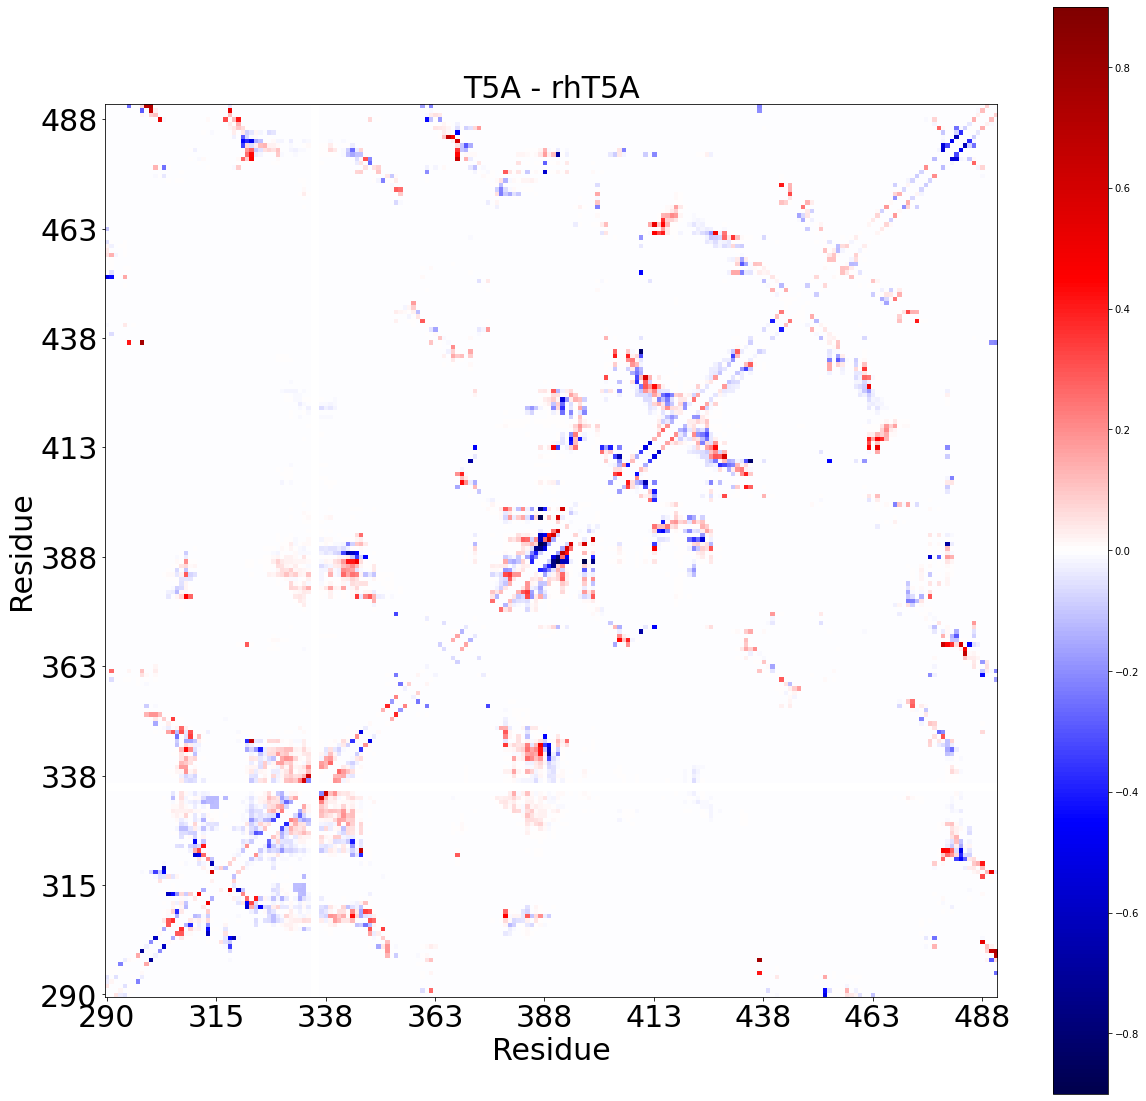

In [17]:
figure(figsize = (20,20))
imshow(avg_contacts_2d_withnans[0]-avg_contacts_2d[0],origin = "lower", cmap = "seismic",vmax = .9, vmin = -.9)

title("T5A - rhT5A",fontsize = 30)
xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)

_=xticks(arange(len(systems[0][0].residues.resids))[::25],systems[0][0].residues.resids[::25],fontsize = 30)
_=yticks(arange(len(systems[0][0].residues.resids))[::25],systems[0][0].residues.resids[::25],fontsize = 30)
colorbar()

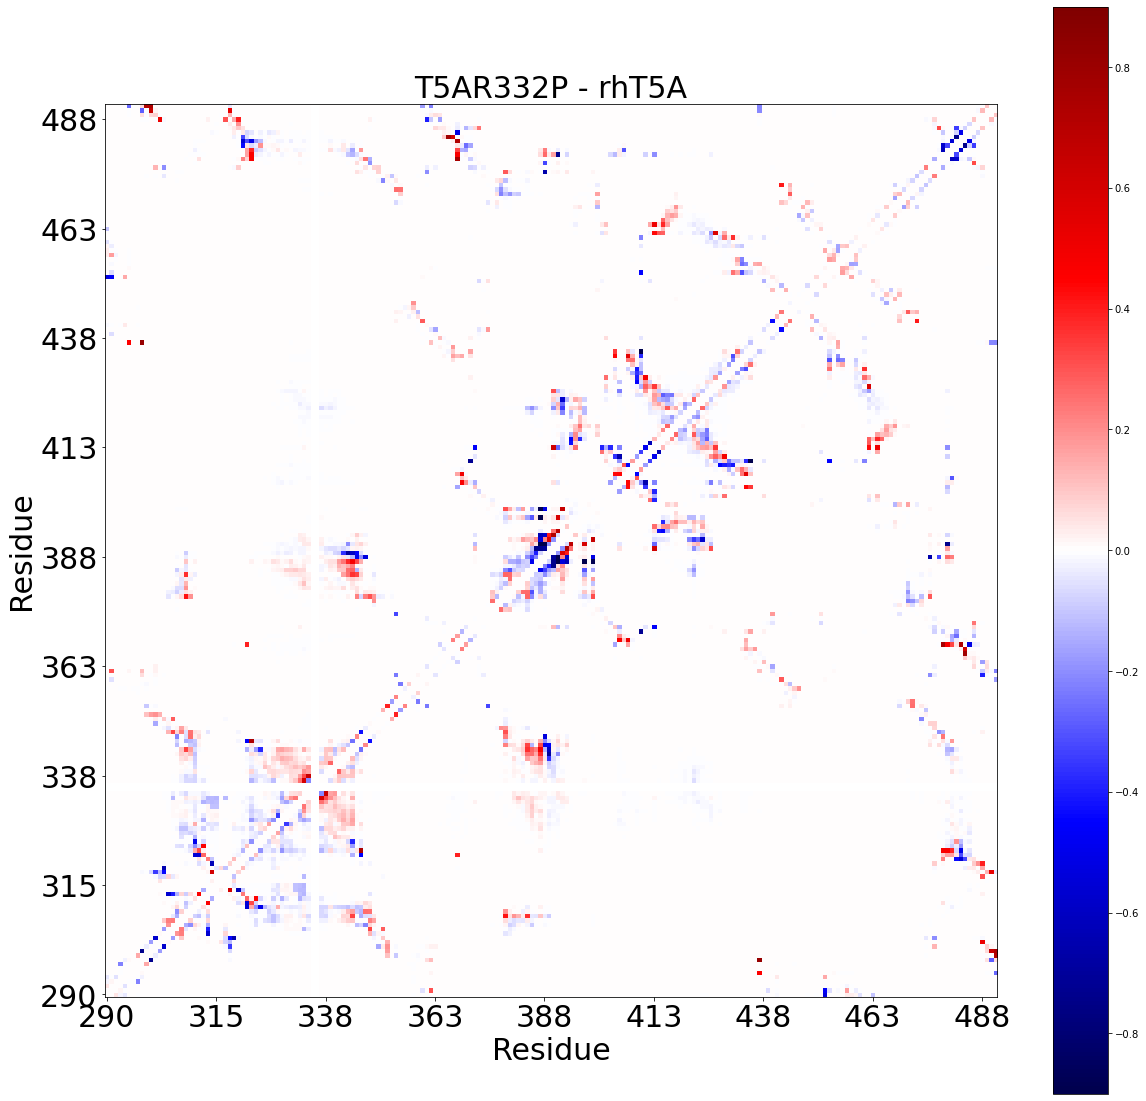

In [18]:
figure(figsize = (20,20))
imshow(avg_contacts_2d_withnans[1]-avg_contacts_2d[0],origin = "lower", cmap = "seismic",vmax = .9, vmin = -.9)

title("T5AR332P - rhT5A",fontsize = 30)
xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)

_=xticks(arange(len(systems[0][0].residues.resids))[::25],systems[0][0].residues.resids[::25],fontsize = 30)
_=yticks(arange(len(systems[0][0].residues.resids))[::25],systems[0][0].residues.resids[::25],fontsize = 30)
colorbar()